# Telco Customer Churn Analysis

**Author:** Siddarth Nayak
**Dataset:** `synthetic_customer_churn_100k.csv` (100,000 customer records)

## Business Question
Which customers are most likely to churn, and what should the business
prioritize to reduce revenue loss from churn?

## Approach
1. Load and inspect the raw data
2. Clean it (document every decision)
3. Explore churn patterns with SQL and visualizations
4. Build a predictive model
5. Translate findings into business recommendations


## 1. Load & Inspect Raw Data

In [1]:
import pandas as pd
import numpy as np

raw = pd.read_csv("../data/raw/synthetic_customer_churn_100k.csv")
print("Shape:", raw.shape)
raw.head()


Shape: (100000, 9)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No


In [2]:
print("Missing values:\n", raw.isna().sum())
print("\nChurn distribution:\n", raw["Churn"].value_counts(normalize=True))


Missing values:
 CustomerID        0
Age               0
Gender            0
Tenure            0
MonthlyCharges    0
Contract          0
PaymentMethod     0
TotalCharges      0
Churn             0
dtype: int64

Churn distribution:
 Churn
No     0.66856
Yes    0.33144
Name: proportion, dtype: float64


**Data quality check:** `TotalCharges` should never be negative (it's a
billed dollar amount), so let's check.

In [3]:
n_negative = (raw["TotalCharges"] < 0).sum()
print(f"Rows with negative TotalCharges: {n_negative} ({n_negative/len(raw):.2%})")
raw[raw["TotalCharges"] < 0].head()


Rows with negative TotalCharges: 265 (0.27%)


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
667,668,56,Male,2,14.58,Two year,Electronic check,-13.55,No
1019,1020,28,Female,5,11.13,Month-to-month,Credit card,-80.24,Yes
1337,1338,23,Female,4,25.92,Month-to-month,Bank transfer,-19.18,Yes
2090,2091,74,Male,3,26.68,Month-to-month,Mailed check,-22.84,Yes
2407,2408,73,Female,1,33.34,Month-to-month,Electronic check,-18.84,Yes


## 2. Data Cleaning

**Decision:** Rather than dropping the 265 rows with negative `TotalCharges`,
reconstruct them from `Tenure * MonthlyCharges`. This is justified because
in the valid rows, `TotalCharges` correlates at 0.9998 with
`Tenure * MonthlyCharges` — that's essentially the formula the values were
generated from, so recomputing is a safe fix rather than a guess.

Full cleaning logic lives in `src/data_cleaning.py`. Re-running it here for
the notebook's own record.

In [4]:
import subprocess
result = subprocess.run(["python3", "../src/data_cleaning.py"], capture_output=True, text=True)
print(result.stdout)


In [5]:
df = pd.read_csv("../data/processed/telco_clean.csv")
df.head()


,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn,TenureGroup,AgeGroup,ChurnFlag
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No,4-6 yr,56-65,0
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No,2-4 yr,66-80,0
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No,0-1 yr,46-55,0
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes,1-2 yr,26-35,1
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No,4-6 yr,56-65,0


## 3. SQL Analysis

Ten business-framed SQL queries were run against a SQLite database built
from the cleaned data (`sql/analysis_queries.sql`). Key results below.

In [6]:
import sqlite3
conn = sqlite3.connect("../data/processed/telco.db")

q_overall = pd.read_sql_query('''
    SELECT COUNT(*) AS total_customers,
           SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) AS churned,
           ROUND(100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate_pct
    FROM customers
''', conn)
q_overall


,total_customers,churned,churn_rate_pct
0,100000,33144,33.14


In [7]:
q_contract = pd.read_sql_query('''
    SELECT Contract, COUNT(*) AS customers,
           ROUND(100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate_pct
    FROM customers GROUP BY Contract ORDER BY churn_rate_pct DESC
''', conn)
q_contract


,Contract,customers,churn_rate_pct
0,Month-to-month,54915,46.56
1,Two year,19824,16.88
2,One year,25261,16.75


In [8]:
q_segment = pd.read_sql_query('''
    SELECT COUNT(*) AS customers_in_segment,
           ROUND(100.0*SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)/COUNT(*),2) AS churn_rate_pct,
           ROUND(SUM(CASE WHEN Churn='Yes' THEN MonthlyCharges ELSE 0 END),2) AS mrr_at_risk
    FROM customers WHERE Contract='Month-to-month' AND TenureGroup='0-1 yr'
''', conn)
print("Highest-risk segment: Month-to-month contract + <1 year tenure")
q_segment


Highest-risk segment: Month-to-month contract + <1 year tenure


,customers_in_segment,churn_rate_pct,mrr_at_risk
0,9148,77.54,608713.76


The full set of 10 queries and their results are saved in `reports/sql_query_results.md`.

## 4. Exploratory Data Analysis

Charts generated by `src/eda.py`, shown here inline.

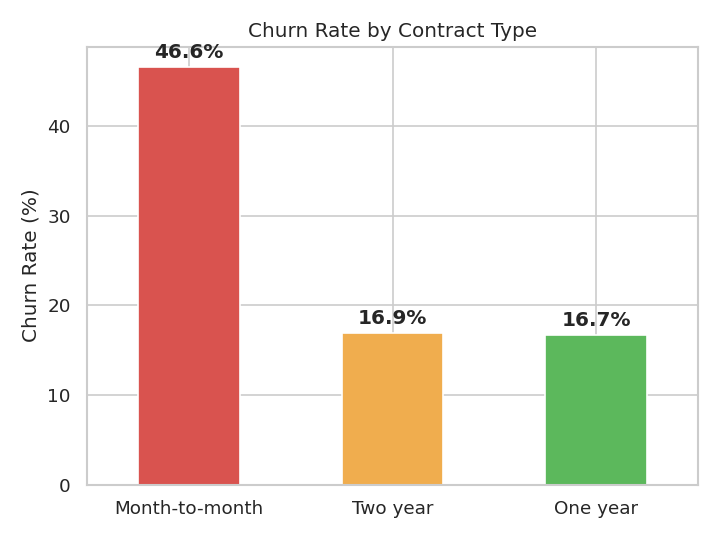

In [9]:
from IPython.display import Image, display
display(Image("../images/churn_by_contract.png"))


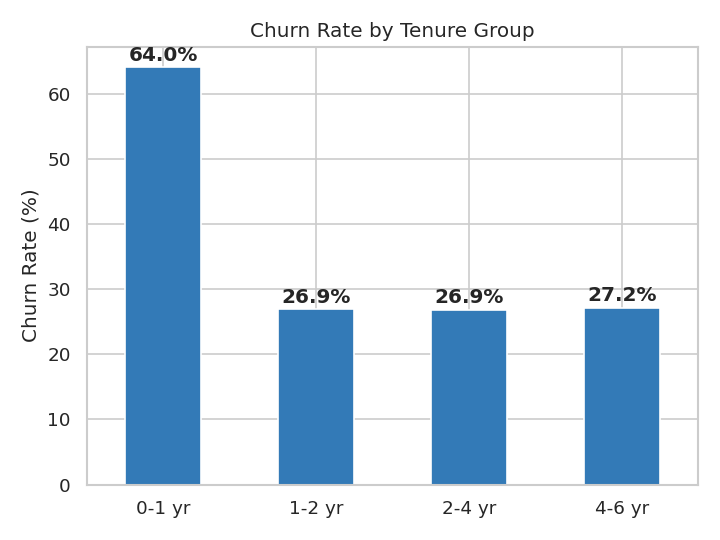

In [10]:
display(Image("../images/churn_by_tenure.png"))


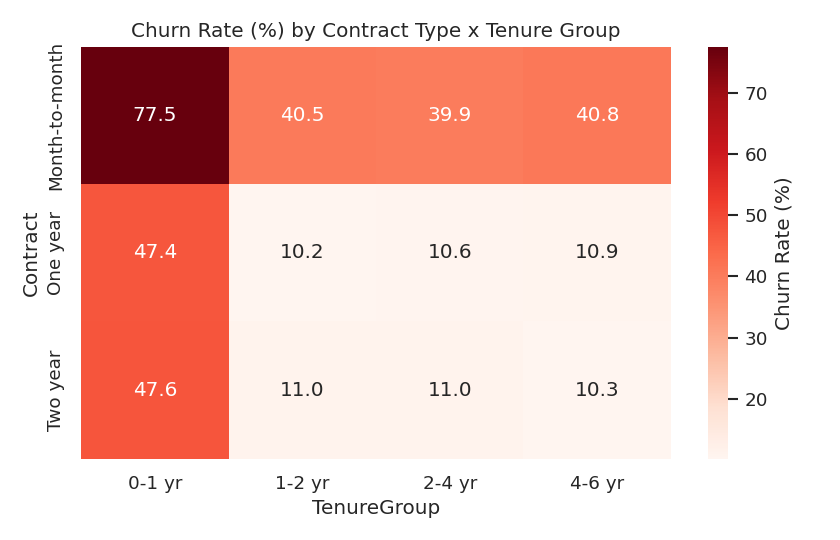

In [11]:
display(Image("../images/churn_heatmap_contract_tenure.png"))


**Interaction effect:** a brand-new customer churns at ~47-78% regardless of contract type — tenure has to build up before a longer contract's protective effect fully kicks in.

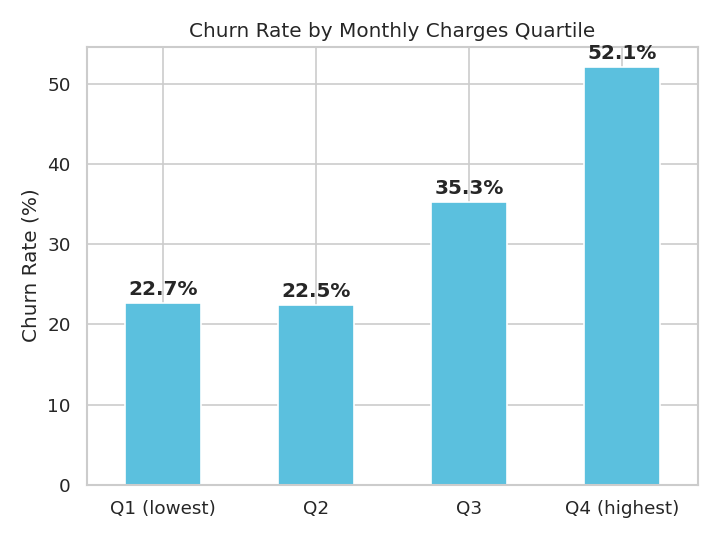

In [12]:
display(Image("../images/churn_by_charge_quartile.png"))


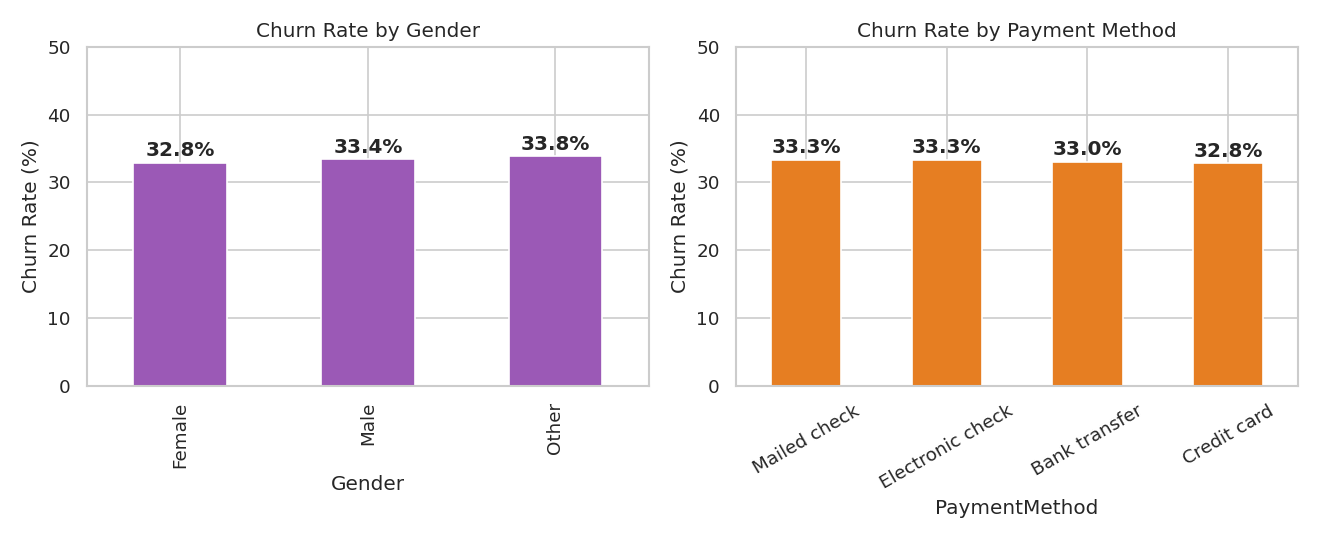

In [13]:
display(Image("../images/churn_by_demographics.png"))


**Gender and payment method are flat across categories** — no meaningful relationship to churn. This rules out demographic-based retention targeting.

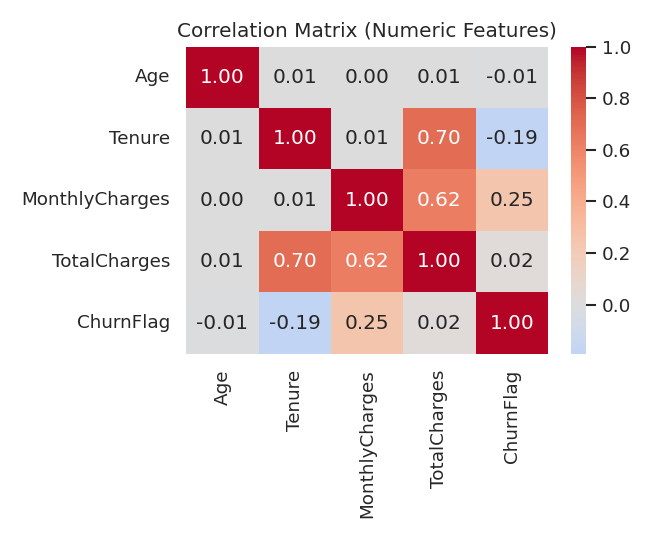

In [14]:
display(Image("../images/correlation_heatmap.png"))


## 5. Predictive Modeling

Two models: Logistic Regression (interpretable baseline) and Random Forest
(stronger, non-linear). Full code in `src/model.py`.

In [15]:
metrics = pd.read_csv("../reports/model_metrics.csv", index_col=0)
metrics


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7233,0.6077,0.4660,0.5275,0.7719
Random Forest,0.7622,0.6686,0.5601,0.6096,0.8062


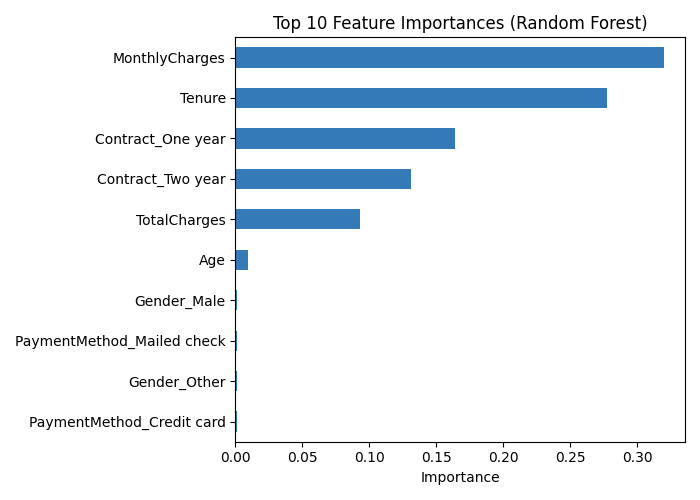

In [16]:
display(Image("../images/feature_importance.png"))


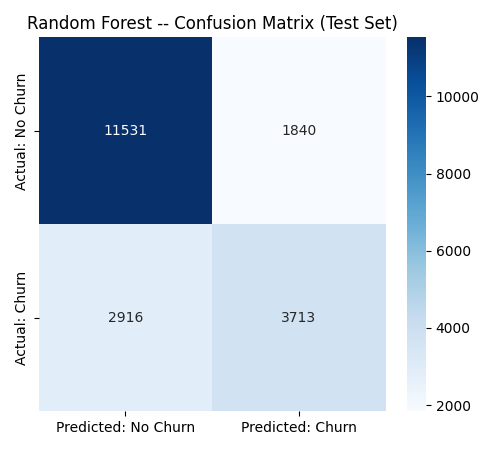

In [17]:
display(Image("../images/confusion_matrix.png"))


Random Forest reaches **ROC-AUC 0.806**, and its feature importances
independently confirm the SQL/EDA findings: `MonthlyCharges`, `Tenure`, and
`Contract` account for ~89% of predictive weight combined, while `Age`,
`Gender`, and `PaymentMethod` together account for under 2%.

## 6. Key Findings & Recommendations

1. **Churn is concentrated, not evenly spread**: month-to-month customers in
   their first year churn at 77.5% — a segment of ~9,148 customers
   representing $608,714/month in at-risk revenue.
2. **Contract type and tenure are the dominant drivers**, followed by
   monthly charges. Demographics (age, gender) and payment method have
   essentially no relationship to churn.
3. **Recommendation:** prioritize retention spend on converting new
   month-to-month customers to annual contracts within their first 90 days,
   rather than spreading retention budget evenly or by demographic segment.

Full write-up with limitations and next steps: `reports/business_report.md`.
